In [1]:
PP[u_, v_, A_, Q_] := u^2((1-u)(u^2+A^2)-Q*u*v);
QQ[u_, v_, A_, B_] := B(u-v)(u^2+A^2)v;

-Graphics-
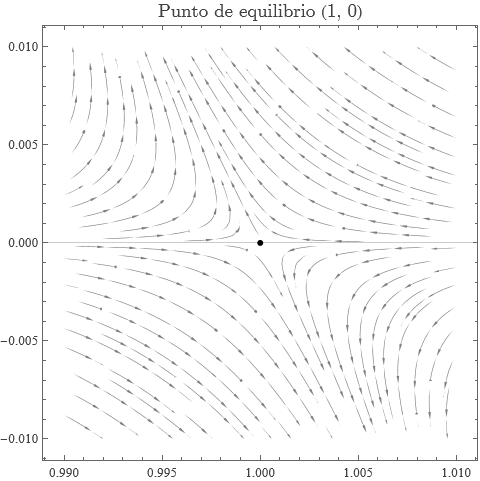

In [3]:
A = RandomReal[{0.00001, 0.99999}]; B = RandomReal[{0.00001, 2}]; Q = RandomReal[{0.00001, 2}];
equnocero = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0.99, 1.01}, {v, -0.01, 0.01},
  Epilog -> {PointSize[Medium], Point[{1, 0}]},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart",
  PlotLabel -> Style["Punto de equilibrio (1, 0)", 
   FontFamily -> "CMU Serif", 
   FontSize -> 14
  ]
]

In [5]:
(* Export["puntoDeEquilibrio(1,0).pdf", equnocero] *)

-Graphics-
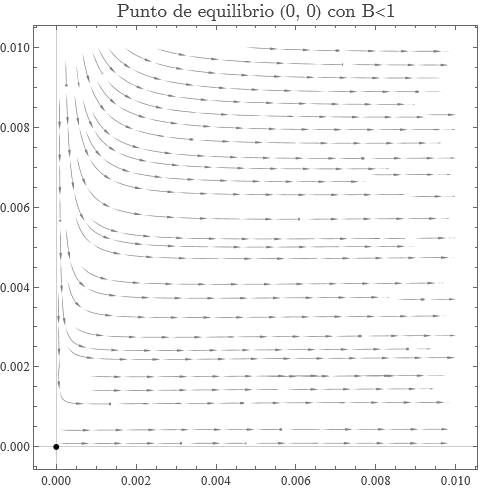

In [6]:
A = RandomReal[{0.00001, 0.99999}]; B = RandomReal[{0.00001, 0.5}]; Q = RandomReal[{0.00001, 2}];
eqcero = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0, 0.01}, {v, 0, 0.01},
  Epilog -> {PointSize[Medium], Point[{0, 0}]},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart",
  PlotLabel -> Style["Punto de equilibrio (0, 0) con B<1", 
   FontFamily -> "CMU Serif", 
   FontSize -> 14
  ]
]

In [8]:
(* Export["puntoDeEquilibrio(0,0)conBmenor1.pdf", eqcero] *)

-Graphics-
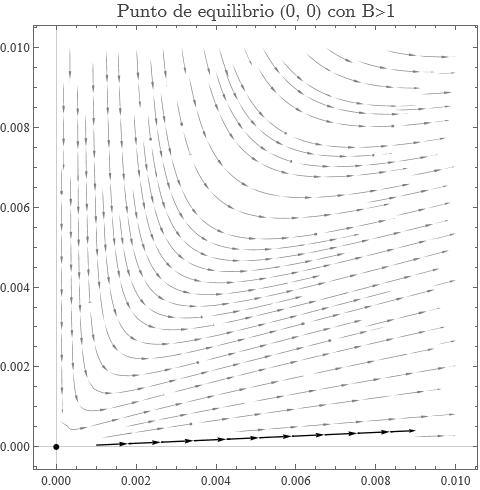

In [9]:
A = RandomReal[{0.00001, 0.99999}]; B = RandomReal[{1.00001, 2}]; Q = RandomReal[{0.00001, 2}];
x = 0.001;
y = (B-1)*x/B;

eqceroconSepar = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0, 0.01}, {v, 0, 0.01},
  Epilog -> {PointSize[Medium], Point[{0, 0}]},
  StreamPoints -> {{{{x, y}, Black}, Automatic}},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart",
  PlotLabel -> Style["Punto de equilibrio (0, 0) con B>1", 
   FontFamily -> "CMU Serif", 
   FontSize -> 14
  ]
]

In [13]:
(* Export["puntoDeEquilibrio(0,0)conBmayor1.pdf", eqceroconSepar] *)

0.0210657
{0.000213549, 2.07804}
{0.000561628 + 0.00790862 I, 0.000561628 - 0.00790862 I}
{0.00112326, 0.00112326}
{0.00193138, 0.000326632}
{0. + 0.0111562 I, 0. - 0.0111562 I}
{-0.0554022 + 0.055961 I, -0.0554022 - 0.055961 I}
{-0.110804, -0.110804}
{-0.0701681, -0.259176}
-Graphics-   -Graphics-     -Graphics-

-Graphics-   SpanFromLeft

-Graphics-   -Graphics-     -Graphics-
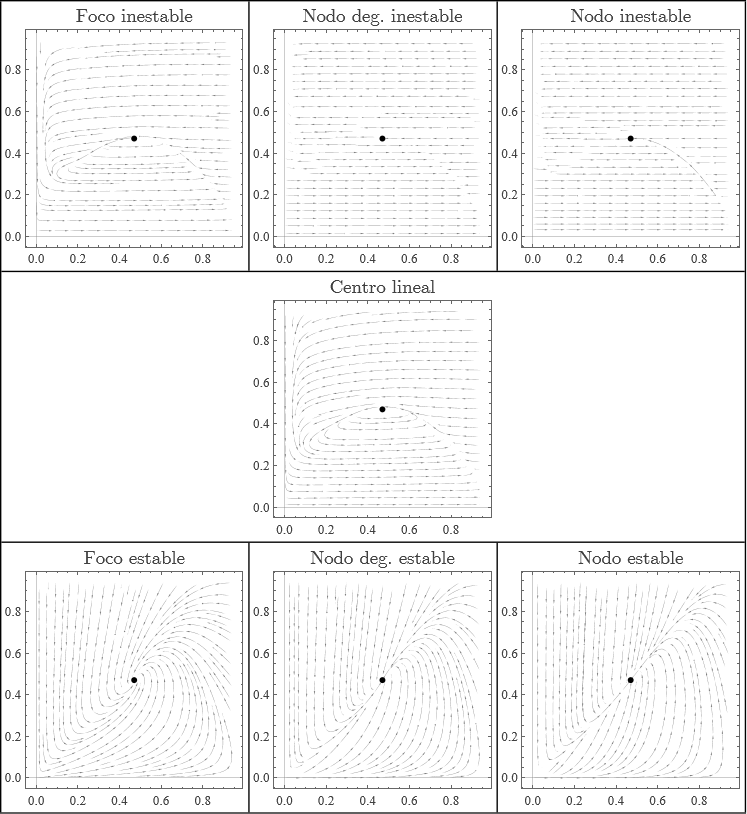

In [14]:
Clear[B]
H = RandomReal[{0.00001, 0.49999}];
maxA = H * Sqrt[1 - 2*H];
A = RandomReal[{0.00001, maxA - 0.00001}]; 
Q = (1 - H)(A^2 + H^2)/H^2;

Bc = (H^2(1 - 2H) - A^2)/(A^2 + H^2)

trA[B_] := -H(B(A^2 + H^2) + H^2(2H - 1) + A^2);
detA[B_] :=  B H^2 (A^2 + H^2)(H^3 + A^2(2 - H));
Delta[B_] := trA[B]^2 - 4 detA[B];

BDeltazero = B /. NSolve[Delta[B] == 0 && B > 0, B, Reals]

retrato[valB_, titulo_] := StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, valB]}, {u, 0, 2*H}, {v, 0, 2*H},
  Epilog -> {PointSize[Medium], Point[{H, H}]},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart",
  PlotLabel -> Style[titulo, 
   FontFamily -> "CMU Serif", 
   FontSize -> 14
  ]
];
vp[valB_] := {(trA[valB] + Sqrt[Delta[valB]])/2, (trA[valB] - Sqrt[Delta[valB]])/2}; 

vp[(BDeltazero[[1]] + Bc)/2]
vp[BDeltazero[[1]]]
vp[BDeltazero[[1]]/2]

vp[Bc]

vp[(Bc + BDeltazero[[2]])/2]
vp[BDeltazero[[2]]]
vp[BDeltazero[[2]] + 1]

eqHH = Grid[{
  {retrato[(BDeltazero[[1]] + Bc)/2,  "Foco inestable"],
   retrato[BDeltazero[[1]], "Nodo deg. inestable"],
   retrato[BDeltazero[[1]]/2,  "Nodo inestable"]},
  {retrato[Bc, "Centro lineal"], SpanFromLeft},
  {retrato[(Bc + BDeltazero[[2]])/2,   "Foco estable"],
   retrato[BDeltazero[[2]], "Nodo deg. estable"],
   retrato[BDeltazero[[2]] + 1,   "Nodo estable"]}
}, Frame -> All]

In [34]:
(*Export["puntoDeEquilibrio(H,H).pdf", eqHH]*)

0.0589
1.59278
0.109508
-Graphics-
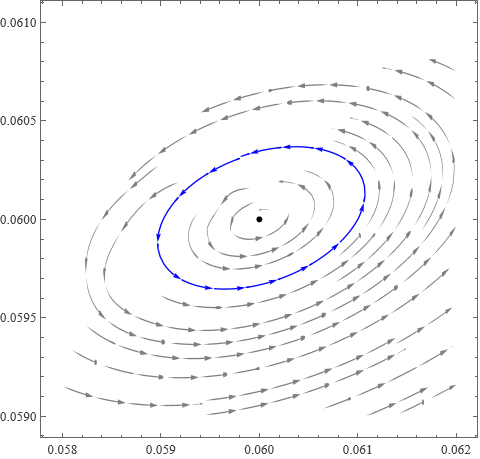

In [35]:
A = 0.05; H = 0.06;
L1 = (A^2*(-1 + H)*H*(-4*A^2*H^3 + (-3 + H)*H^5 + A^4*(4 + 3*(-3 + H)*H)))/(2*(A^2 + H^2)*(-(A^2*(-2 + H)) + H^3)*(A^2 + H^2*(-1 + 2*H)))
Q = (1 - H)(A^2 + H^2)/H^2
Bc = (H^2(1 - 2H) - A^2)/(A^2 + H^2)

hopfsub = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, Bc]}, {u, 0.058, 0.062}, {v, 0.059, 0.061},
  Epilog -> {PointSize[Medium], Point[{H, H}]},
  StreamPoints -> {{(*{{0.1, 0.05458}, Black}, {{0.08, 0.07}, Black},*) {{0.061, 0.06}, Blue}, Automatic}},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]

In [40]:
CopyToClipboard[QQ[x, y, A, Bc]]

In [41]:
(*Export["HopfSubCentrolineal.pdf", hopfsub]*)

-8
1.18241 10
1.22111
0.367609
-Graphics-
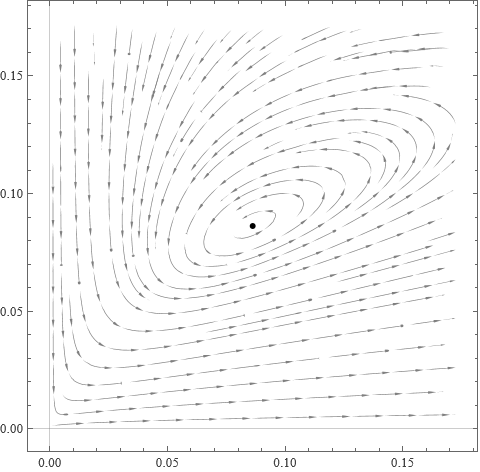

In [42]:
A = 0.05; H = 0.0862168;
L1 = (A^2*(-1 + H)*H*(-4*A^2*H^3 + (-3 + H)*H^5 + A^4*(4 + 3*(-3 + H)*H)))/(2*(A^2 + H^2)*(-(A^2*(-2 + H)) + H^3)*(A^2 + H^2*(-1 + 2*H)))
Q = (1 - H)(A^2 + H^2)/H^2
Bc = (H^2(1 - 2H) - A^2)/(A^2 + H^2)

hopfdeg = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, Bc]}, {u, 0, 2*H}, {v, 0, 2*H},
  Epilog -> {PointSize[Medium], Point[{{H, H}}]},
  (*StreamPoints -> {{{{0.289, 0.289}, Black}, {{0.32, 0.32}, Gray}, {{0.35, 0.35}, Gray}, {{0.2, 0.4}, Gray}, Automatic}},*)
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]

In [47]:
(*Export["HopfDegCentrolineal.pdf", hopfdeg]*)

-0.0250864
0.609375
0.181538
-Graphics-
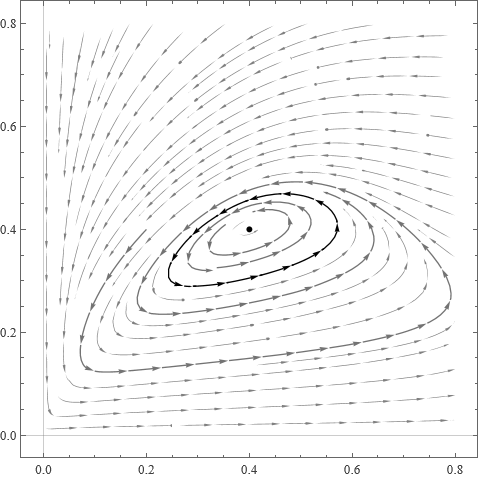

In [48]:
A = 0.05; H = 0.4;
L1 = (A^2*(-1 + H)*H*(-4*A^2*H^3 + (-3 + H)*H^5 + A^4*(4 + 3*(-3 + H)*H)))/(2*(A^2 + H^2)*(-(A^2*(-2 + H)) + H^3)*(A^2 + H^2*(-1 + 2*H)))
Q = (1 - H)(A^2 + H^2)/H^2
Bc = (H^2(1 - 2H) - A^2)/(A^2 + H^2)

hopfsuper = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, Bc]}, {u, 0, 2*H}, {v, 0, 2*H},
  Epilog -> {PointSize[Medium], Point[{{H, H}}]},
  StreamPoints -> {{{{0.289, 0.289}, Black}, {{0.32, 0.32}, Directive[Opacity[.55], Black]}, {{0.35, 0.35}, Directive[Opacity[.55], Black]}, {{0.2, 0.4}, Directive[Opacity[.55], Black]}, Automatic}},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]

In [53]:
(*Export["HopfSuperCentrolineal.pdf", hopfsuper]*)

-Graphics-
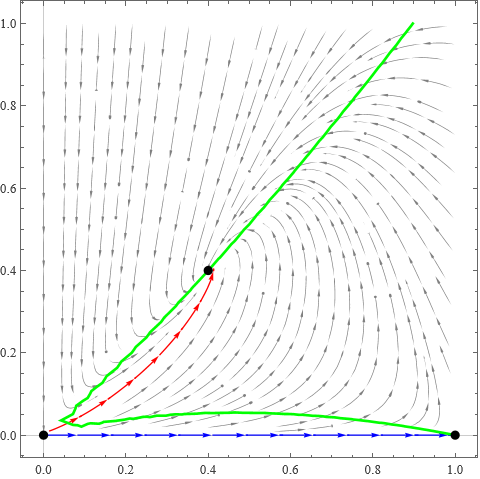

In [54]:
B = 1.5; m = (B-1)/B;

plot = StreamPlot[{u^2((1-u)(u^2+A^2)-Q*u*v), B(u-v)(u^2+A^2)v}, {u, 0, 1}, {v, 0, 1},
  Epilog -> {PointSize[Large], Point[{{0, 0}, {1, 0}, {H, H}}]},
  StreamPoints -> {{{{0.5, 0}, Blue}, {{0.06, 0.03}, Red}, Automatic}},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
];

iso = ContourPlot[QQ[u, v, A, B] - m*PP[u, v, A, Q] == 0, {u, 0, 1}, {v, 0, 1}, 
   ContourStyle -> {Thick, Green}];

varInesOrigen = Show[plot, iso]

In [58]:
(*Export["VariedadesInestablesOrigenBmayor1.pdf", varInesOrigen]*)

-21
-1.69407 10
-Graphics-
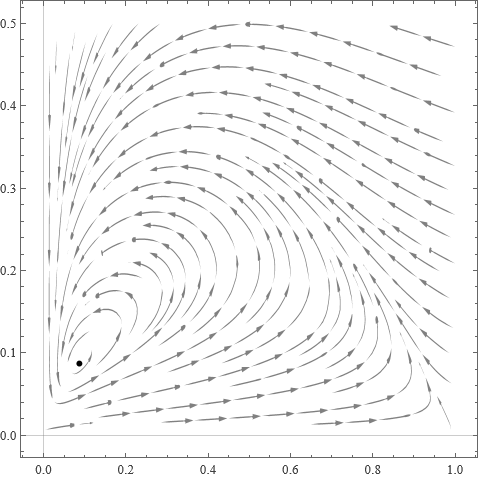

In [59]:
Clear[A, B, H, Q, u, v]; A = 0.05059103559978497; B = 0.36435231308468385; Q = 1.222017313071541;

H = 0.08696600618632838 ;

primerLyapunov = (3H(3-H)-4)A^4 + 4H^3A^2 + (3-H)H^5

hopfGeneral = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0, 1}, {v, 0, .5},
  StreamColorFunction -> None,
  Epilog -> {PointSize[Medium], Point[{H, H}]},
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]


In [63]:
(*Export["HopfGeneralCentrolineal.pdf", hopfGeneral]*)

0.0780074
0.0642552
1.59364
1
-Graphics-
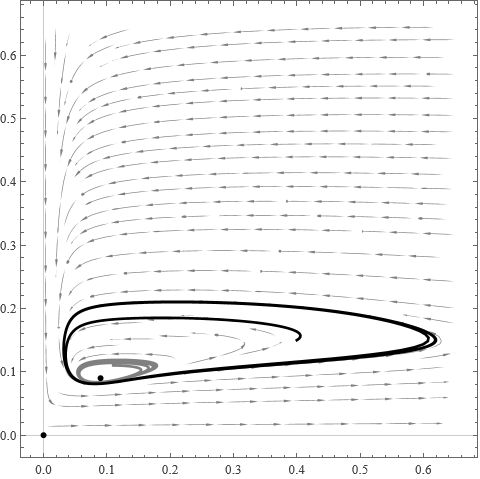

In [194]:
Clear[A, B, H, Q, u, v, x, y];

H = 0.09;
A = Sqrt[(2H^3+H^2(1-H)Sqrt[3H(4-H)])/(4-3H(3-H))] + 0.025
B = (H^2 (1-2H) - A^2)/(A^2+H^2) + 0.025
Q = (1-H)(A^2+H^2)/H^2

Sign[(4 - 3H(3-H))A^4 - 4H^3A^2 - (3-H)H^5]

Tmax = 10000000;

sol = NDSolve[{x'[t] == PP[x[t], y[t], A, Q], y'[t] == QQ[x[t], y[t], A, B],
   x[0] == 0.4, y[0] == 0.15}, {x, y}, {t, 0, Tmax}][[1]];

solInv = NDSolve[{x'[t] == PP[x[t], y[t], A, Q], y'[t] == QQ[x[t], y[t], A, B],
   x[0] == 0.11, y[0] == 0.11}, {x, y}, {t, 0, -Tmax}][[1]];

trajOuter = ParametricPlot[
   Evaluate[{x[t], y[t]} /. sol],
   {t, 0, Tmax},
   PlotStyle -> {Thick, Black},
   PlotPoints -> 50000
];

trajInner = ParametricPlot[
   Evaluate[{x[t], y[t]} /. solInv],
   {t, 0, -1000000},
   PlotStyle -> {Thick, Gray},
   PlotPoints -> 1000
];

r = 0.2;

stream = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0, 0.65}, {v, 0, 0.65},  (*H-r, H+r*)
  Epilog -> {PointSize[Medium], Point[{{0, 0}, {1, 0}, {H, H}}]},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]; 

hopfsub2 = Show[stream, trajInner, trajOuter]

In [208]:
(*Export["HopfSubCentrolinealVersion2.pdf", hopfsub2]*)

HopfSubCentrolinealVersion2.pdf

0.707
-Graphics-
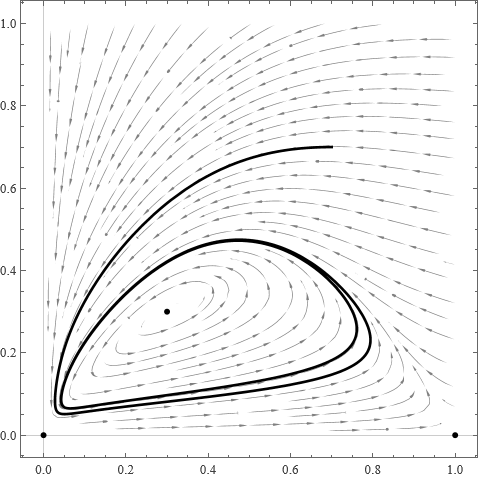

In [220]:
Clear[A, B, H, Q, u, v, x, y];

H = 0.3;
A = 0.03;
B = 0.3;
Q = (1-H)(A^2+H^2)/H^2

Tmax = 100000;

sol = NDSolve[{x'[t] == PP[x[t], y[t], A, Q], y'[t] == QQ[x[t], y[t], A, B],
   x[0] == 0.7, y[0] == 0.7}, {x, y}, {t, 0, Tmax}][[1]];

trajOuter = ParametricPlot[
   Evaluate[{x[t], y[t]} /. sol],
   {t, 0, Tmax},
   PlotStyle -> {Thick, Black},
   PlotPoints -> 10000
];

stream = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0, 1}, {v, 0, 1},  (*H-r, H+r*)
  Epilog -> {PointSize[Medium], Point[{{0, 0}, {1, 0}, {H, H}}]},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]; 

hFocoInestable = Show[stream, trajOuter]

In [219]:
(*Export["hFocoInestable.pdf", hFocoInestable]*)

hFocoInestable.pdf